In [133]:
from pathlib import Path
from textwrap import fill
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


In [134]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')

BIODYNAMO_DIR = ROOT / 'Biodynamo' / 'mechanics_externalImpulse' / 'results_3s_force'
CHASTE_DIR = ROOT / 'Chaste' / 'MechanicsWithFriction'
COMPUTIX_DIR = ROOT / 'CompuTiX' / 'external_impulse' 
PHYSICELL_DIR = ROOT / 'PhysiCell' / 'results' / 'mechanics_external_impulse' /'dt_0.001'
TiSIM_DIR = ROOT / 'Tisim' / 'mechanics_external_impulse'
analytical_dir = ROOT / 'analytical_solutions' / 'mechanics'


In [135]:
COLORS = {
    'PhysiCell': '#4daf4a',  # Green
    'BioDynaMo': '#ff7f00',  # Orange
    'Chaste':    '#377eb8',  # Blue
    'TiSim':     '#984ea3',  # Purple
    'CompuTiX':  '#fd2a2a',  # Pink
}

In [136]:
# ── BioDynaMo ──────────────────────────────────────────────────────────
bdm_pos_raw = pd.read_csv(BIODYNAMO_DIR / 'positions.csv', sep='\t', header=None, names=['time', 'xyz'])
bdm_pos_raw['x'] = bdm_pos_raw['xyz'].str.strip().str.split(',').str[0].astype(float)
bdm_spd_raw = pd.read_csv(BIODYNAMO_DIR / 'speeds.csv', sep='\t', header=None, names=['time', 'vxyz'])
bdm_spd_raw['vx'] = bdm_spd_raw['vxyz'].str.strip().str.split(',').str[0].astype(float)
bdm_time = bdm_pos_raw['time'].values
bdm_x    = bdm_pos_raw['x'].values    # µm
bdm_vx   = bdm_spd_raw['vx'].values   # µm/s

# ── Chaste ─────────────────────────────────────────────────────────────
chaste_loc = pd.read_csv(CHASTE_DIR / 'node_locations.dat', sep='\t', header=None, names=['time', 'xy'])
chaste_loc['x'] = chaste_loc['xy'].str.strip().str.split().str[0].astype(float)
chaste_vel = pd.read_csv(CHASTE_DIR / 'cell_velocities.dat', sep='\t', header=None, names=['time', 'vals'])
vel_cols = chaste_vel['vals'].str.strip().str.split(expand=True).astype(float)
chaste_time = chaste_loc['time'].values
chaste_x    = chaste_loc['x'].values    # µm
chaste_vx   = vel_cols[3].values      # µm/s

# ── CompuTiX ───────────────────────────────────────────────────────────
with open(COMPUTIX_DIR / 'impulse_benchmark.yaml') as f:
    ctix = yaml.safe_load(f)
ctix_time  = np.array(ctix['t']['values'])
ctix_x_imp = np.array(ctix['x_implicit']['values']) * 1e6   # m → µm
ctix_v_imp = np.array(ctix['v_implicit']['values']) * 1e6   # m/s → µm/s
ctix_x_exp = np.array(ctix['x_explicit']['values']) * 1e6
ctix_v_exp = np.array(ctix['v_explicit']['values']) * 1e6

# ── PhysiCell ──────────────────────────────────────────────────────────
pc_df   = pd.read_csv(PHYSICELL_DIR / 'physicell_mechanics_external_impulse_data.csv')
pc_time = pc_df['dt'].values * 60   # min → s
pc_x    = pc_df['x'].values         # µm
pc_vx   = pc_df['mvx'].values / 60  # µm/min → µm/s

# ── TiSim ──────────────────────────────────────────────────────────────
tisim_df   = pd.read_csv(TiSIM_DIR / 'mechanics_external_impulse.csv')
tisim_time = tisim_df['time'].values
tisim_x    = tisim_df['position'].values 
tisim_vx   = tisim_df['velocity'].values
# Analytical solution
analytical_df = pd.read_csv(analytical_dir / 'analytical_values.csv')


plotting everything below

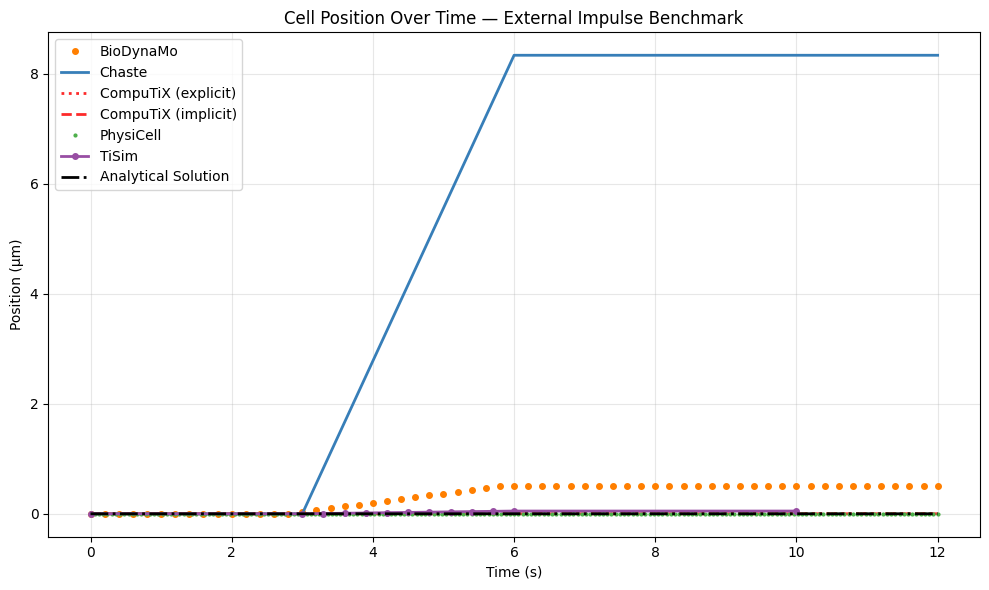

In [137]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bdm_time,    bdm_x,       label='BioDynaMo',              lw=2,marker='o',linestyle='None', ms=4, color=COLORS['BioDynaMo'])
ax.plot(chaste_time, chaste_x,    label='Chaste',                 lw=2, color=COLORS['Chaste'])
ax.plot(ctix_time,   ctix_x_exp,  label='CompuTiX (explicit)',    lw=2, ls=':', color=COLORS['CompuTiX'])
ax.plot(ctix_time,   ctix_x_imp,  label='CompuTiX (implicit)',    lw=2, ls='--', color=COLORS['CompuTiX'])
ax.plot(pc_time,     pc_x,        label='PhysiCell',              lw=2, marker='.',linestyle='None', ms=4, color=COLORS['PhysiCell'])
ax.plot(tisim_time,  tisim_x,     label='TiSim',                  lw=2, marker='o', ms=4, color=COLORS['TiSim'])
ax.plot(analytical_df['time_s'], analytical_df['distance_um'], label='Analytical Solution', lw=2, ls='-.', color='black')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (µm)')
ax.set_title('Cell Position Over Time — External Impulse Benchmark')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'ResultAnalysis' / 'plots' / 'mechanics_external_impulse_position.png', dpi=150)
plt.show()


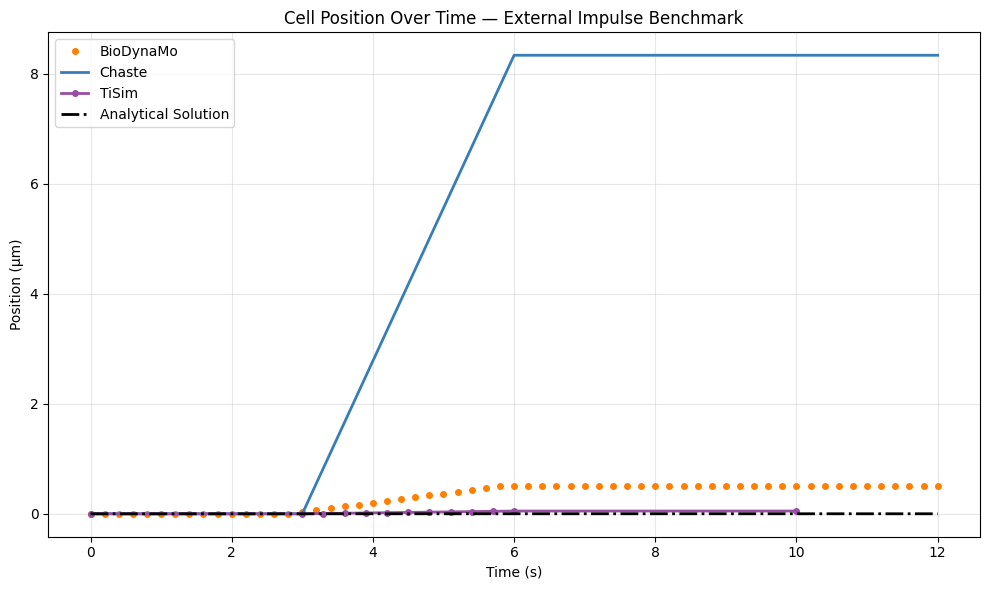

In [138]:
# plotting the ones which are not behaving as expected
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bdm_time,    bdm_x,       label='BioDynaMo',              lw=2,marker='o',linestyle='None', ms=4, color=COLORS['BioDynaMo'])
ax.plot(chaste_time, chaste_x,    label='Chaste',                 lw=2, color=COLORS['Chaste'])
# ax.plot(ctix_time,   ctix_x_exp,  label='CompuTiX (explicit)',    lw=2, ls=':', color=COLORS['CompuTiX'])
# ax.plot(ctix_time,   ctix_x_imp,  label='CompuTiX (implicit)',    lw=2, ls='--', color=COLORS['CompuTiX'])
# ax.plot(pc_time,     pc_x,        label='PhysiCell',              lw=2, marker='.',linestyle='None', ms=4, color=COLORS['PhysiCell'])
ax.plot(tisim_time,  tisim_x,     label='TiSim',                  lw=2, marker='o', ms=4, color=COLORS['TiSim'])
ax.plot(analytical_df['time_s'], analytical_df['distance_um'], label='Analytical Solution', lw=2, ls='-.', color='black')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (µm)')
ax.set_title('Cell Position Over Time — External Impulse Benchmark')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig(ROOT / 'ResultAnalysis' / 'plots' / 'mechanics_external_impulse_position.png', dpi=150)
plt.show()


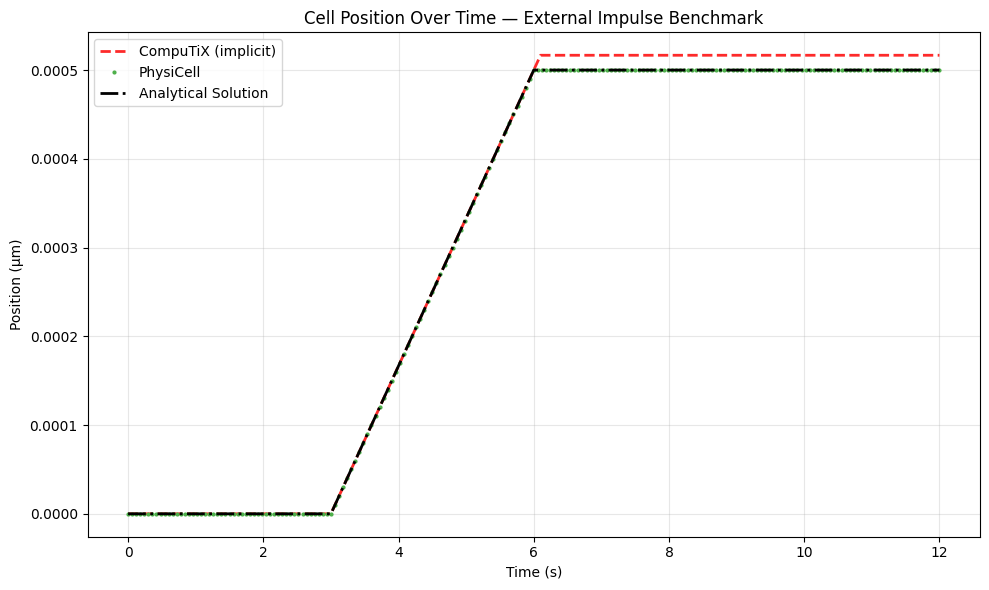

In [139]:
# plotting the ones t behaving as expected
fig, ax = plt.subplots(figsize=(10, 6))

# ax.plot(bdm_time,    bdm_x,       label='BioDynaMo',              lw=2,marker='o',linestyle='None', ms=4, color=COLORS['BioDynaMo'])
# ax.plot(chaste_time, chaste_x,    label='Chaste',                 lw=2, color=COLORS['Chaste'])
# ax.plot(ctix_time,   ctix_x_exp,  label='CompuTiX (explicit)',    lw=2, ls=':', color=COLORS['CompuTiX'])
ax.plot(ctix_time,   ctix_x_imp,  label='CompuTiX (implicit)',    lw=2, ls='--', color=COLORS['CompuTiX'])
ax.plot(pc_time,     pc_x,        label='PhysiCell',              lw=2, marker='.',linestyle='None', ms=4, color=COLORS['PhysiCell'])
# ax.plot(tisim_time,  tisim_x,     label='TiSim',                  lw=2, marker='o', ms=4, color=COLORS['TiSim'])
ax.plot(analytical_df['time_s'], analytical_df['distance_um'], label='Analytical Solution', lw=2, ls='-.', color='black')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (µm)')
ax.set_title('Cell Position Over Time — External Impulse Benchmark')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig(ROOT / 'ResultAnalysis' / 'plots' / 'mechanics_external_impulse_position.png', dpi=150)
plt.show()


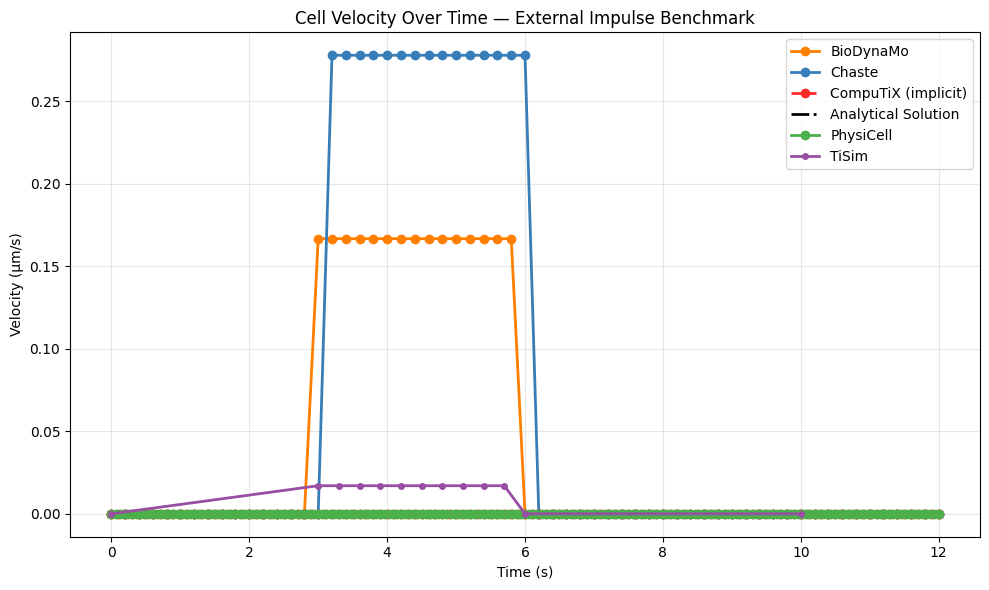

In [140]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bdm_time,    bdm_vx,      label='BioDynaMo',              lw=2,marker = 'o', color=COLORS['BioDynaMo'])
ax.plot(chaste_time, chaste_vx,   label='Chaste',                 lw=2,marker = 'o', color=COLORS['Chaste'])
ax.plot(ctix_time,   ctix_v_imp,  label='CompuTiX (implicit)',    lw=2, ls='--',marker = 'o', color=COLORS['CompuTiX'])
ax.plot(analytical_df['time_s'], analytical_df['velocity_m_per_s'], label='Analytical Solution', lw=2, ls='-.', color='black')
# ax.plot(analytical_df['time_s'], analytical_df['velocity_m_s'], label='Analytical Solution', lw=2, ls='-.', color='black')

ax.plot(pc_time,     pc_vx,       label='PhysiCell',              lw=2,marker = 'o', color=COLORS['PhysiCell'])
ax.plot(tisim_time,  tisim_vx,    label='TiSim',                  lw=2, marker='o', ms=4, color=COLORS['TiSim'])

ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity (µm/s)')
ax.set_title('Cell Velocity Over Time — External Impulse Benchmark')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'ResultAnalysis' / 'plots' / 'mechanics_external_impulse_velocity.png', dpi=150)
plt.show()


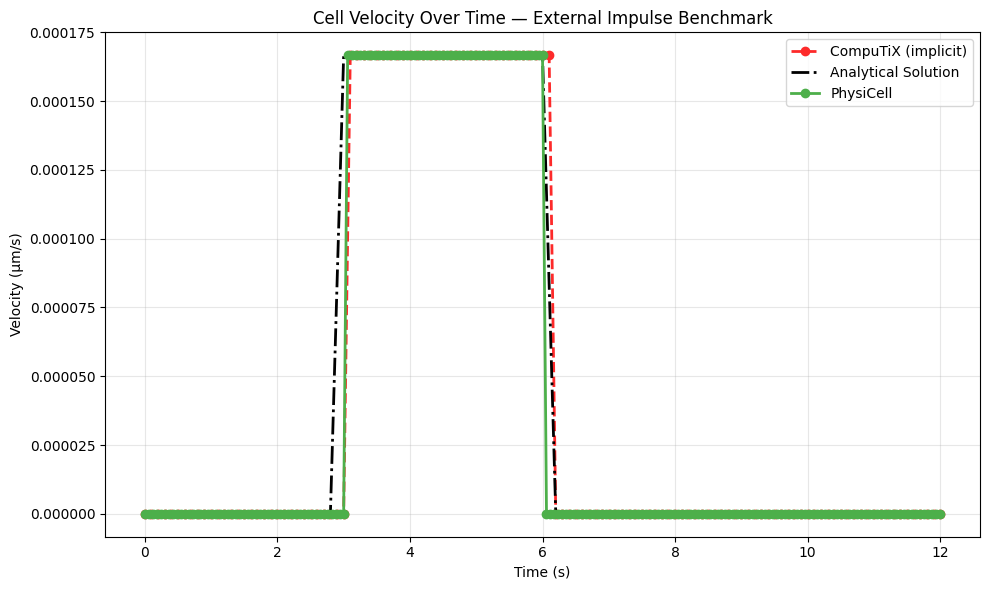

In [141]:
fig, ax = plt.subplots(figsize=(10, 6))

# ax.plot(bdm_time,    bdm_vx,      label='BioDynaMo',              lw=2,marker = 'o', color=COLORS['BioDynaMo'])
# ax.plot(chaste_time, chaste_vx,   label='Chaste',                 lw=2,marker = 'o', color=COLORS['Chaste'])
ax.plot(ctix_time,   ctix_v_imp,  label='CompuTiX (implicit)',    lw=2, ls='--',marker = 'o', color=COLORS['CompuTiX'])
ax.plot(analytical_df['time_s'], analytical_df['velocity_um_per_s'], label='Analytical Solution', lw=2, ls='-.', color='black')
# ax.plot(analytical_df['time_s'], analytical_df['velocity_m_s'], label='Analytical Solution', lw=2, ls='-.', color='black')

ax.plot(pc_time,     pc_vx,       label='PhysiCell',              lw=2,marker = 'o', color=COLORS['PhysiCell'])
# ax.plot(tisim_time,  tisim_vx,    label='TiSim',                  lw=2, marker='o', ms=4, color=COLORS['TiSim'])

ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity (µm/s)')
ax.set_title('Cell Velocity Over Time — External Impulse Benchmark')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'ResultAnalysis' / 'plots' / 'mechanics_external_impulse_velocity.png', dpi=150)
plt.show()


#TODOS
1) Biodynamo check that the resolution of t is correct. 
2) Chaste same
3) tisim provide more timepoints and check that resolution is correct.
Also everyone must explain somewhere in their results what units they are using so that we can compare them